In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [3]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df = pd.get_dummies(df,drop_first=True)

In [5]:
df = df.drop("User ID",axis=1)

In [6]:
y = df[['Purchased']]
x = df.drop('Purchased',axis=1)
x.head()

,Age,EstimatedSalary,Gender_Male
0,19,19000,True
1,35,20000,True
2,26,43000,False
3,27,57000,False
4,19,76000,True


In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=10)

In [8]:
KNN = KNeighborsClassifier(n_neighbors=3)
KNN.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [9]:
y_pred = KNN.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0])

In [10]:
# age : 25,EstimatedSalary : 30000,Gender:male
new_x = [[25,30000,True]]
y_new_pred = KNN.predict(new_x)
if y_new_pred == 0 : 
    print("Not Purchased")
else:
    print("Purchased")

Not Purchased


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [11]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score

In [12]:
confusion_matrix(y_test,y_pred)

array([[47,  5],
       [ 7, 21]])

In [13]:
accuracy_score(y_test,y_pred)

0.85

In [14]:
precision_score(y_test,y_pred)

0.8076923076923077

In [15]:
recall_score(y_test,y_pred)

0.75

In [16]:
# k value 1 to 10
# highest accuracy 
acc_score = []
for i in  range(1,11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    acc = accuracy_score(y_test,y_pred)
    acc_score.append(acc)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_sam

In [17]:
print(max(acc_score))

0.875


In [18]:
conf_matrix=confusion_matrix(y_test,y_pred)

<Axes: >

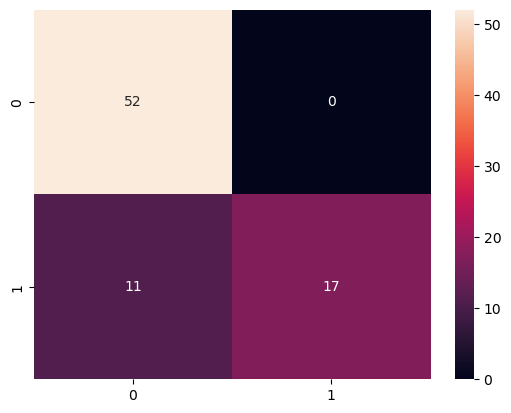

In [19]:
import seaborn as sns
sns.heatmap(conf_matrix,annot=True)

In [20]:
tp=conf_matrix[1,1]
tn=conf_matrix[0,0]
ft=conf_matrix[0,1]
fn=conf_matrix[1,0]
tp,tn,ft,fn

(np.int64(17), np.int64(52), np.int64(0), np.int64(11))

In [21]:
acuracy=(tp+tn)/(tp+tn+ft+fn)
acuracy

np.float64(0.8625)

In [22]:
precision=tp/(tp+ft)
precision

np.float64(1.0)

In [23]:
recall=tp/(tp+fn)
recall

np.float64(0.6071428571428571)

In [25]:
specificity=tn/(tn+ft)
specificity

np.float64(1.0)

In [26]:
df1=pd.read_csv('PlayTennis.csv')
df1

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [46]:
y=df1[['play']]


In [47]:
x=df1.drop('play',axis=1)
x.head()

,outlook,temp,humidity,windy
0,sunny,hot,high,False
1,sunny,hot,high,True
2,overcast,hot,high,False
3,rainy,mild,high,False
4,rainy,cool,normal,False


In [48]:
x=pd.get_dummies(x,drop_first=True)

In [49]:
x.head()

,windy,outlook_rainy,outlook_sunny,temp_hot,temp_mild,humidity_normal
0,False,False,True,True,False,False
1,True,False,True,True,False,False
2,False,False,False,True,False,False
3,False,True,False,False,True,False
4,False,True,False,False,False,True


In [56]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=10,test_size=0.2)

In [57]:
DT=DecisionTreeClassifier(criterion='entropy')

In [58]:
DT.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
y_pred=DT.predict(x_test)
y_pred

array(['no', 'no', 'yes'], dtype=object)

In [62]:
pd.DataFrame({"actual data":y_test.squeeze(),"predict data":y_pred.squeeze()})

,actual data,predict data
3,yes,no
7,no,no
12,yes,yes


[Text(0.5, 0.875, 'x[5] <= 0.5\nentropy = 0.946\nsamples = 11\nvalue = [4, 7]'),
 Text(0.3, 0.625, 'x[2] <= 0.5\nentropy = 0.971\nsamples = 5\nvalue = [3, 2]'),
 Text(0.4, 0.75, 'True  '),
 Text(0.2, 0.375, 'x[1] <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [1, 2]'),
 Text(0.1, 0.125, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3, 0.125, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.375, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.7, 0.625, 'x[0] <= 0.5\nentropy = 0.65\nsamples = 6\nvalue = [1, 5]'),
 Text(0.6, 0.75, '  False'),
 Text(0.6, 0.375, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.8, 0.375, 'x[1] <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [1, 2]'),
 Text(0.7, 0.125, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.9, 0.125, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]')]

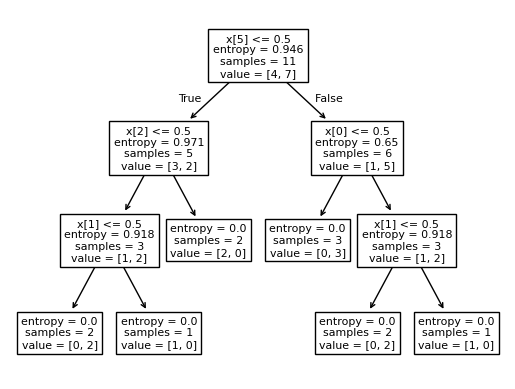

In [64]:
tree.plot_tree(DT)

In [65]:
x_new=[[True,True,False,True,False,True]]
y_new=DT.predict(x_new)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [66]:
y_new

array(['no'], dtype=object)

In [81]:
b=pd.read_csv('drug200.csv')
b

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [82]:
y=b[['Drug']]
y


,Drug
0,drugY
1,drugC
2,drugC
3,drugX
4,drugY
...,...
195,drugC
196,drugC
197,drugX
198,drugX


In [84]:
x=b.drop(['Drug','Na_to_K'],axis=1)
x.head()

,Age,Sex,BP,Cholesterol
0,23,F,HIGH,HIGH
1,47,M,LOW,HIGH
2,47,M,LOW,HIGH
3,28,F,NORMAL,HIGH
4,61,F,LOW,HIGH


In [85]:
x=pd.get_dummies(x,drop_first=True)
x

,Age,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,23,False,False,False,False
1,47,True,True,False,False
2,47,True,True,False,False
3,28,False,False,True,False
4,61,False,True,False,False
...,...,...,...,...,...
195,56,False,True,False,False
196,16,True,True,False,False
197,52,True,False,True,False
198,23,True,False,True,True


In [86]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)

In [100]:
dt=DecisionTreeClassifier(criterion='entropy',max_depth=3)

In [101]:
dt.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [102]:
y_pred=dt.predict(x_test)
y_pred

array(['drugY', 'drugX', 'drugX', 'drugX', 'drugX', 'drugY', 'drugX',
       'drugY', 'drugY', 'drugY', 'drugY', 'drugY', 'drugX', 'drugB',
       'drugB', 'drugX', 'drugX', 'drugY', 'drugX', 'drugX', 'drugX',
       'drugX', 'drugY', 'drugY', 'drugY', 'drugY', 'drugB', 'drugY',
       'drugY', 'drugX', 'drugX', 'drugX', 'drugY', 'drugY', 'drugX',
       'drugX', 'drugX', 'drugY', 'drugY', 'drugY'], dtype=object)

[Text(0.5416666666666666, 0.875, 'x[3] <= 0.5\nentropy = 1.915\nsamples = 160\nvalue = [17, 13, 10, 45, 75]'),
 Text(0.3333333333333333, 0.625, 'x[2] <= 0.5\nentropy = 1.977\nsamples = 113\nvalue = [17, 13, 10, 16, 57]'),
 Text(0.4375, 0.75, 'True  '),
 Text(0.16666666666666666, 0.375, 'x[0] <= 50.5\nentropy = 1.477\nsamples = 62\nvalue = [17, 13, 0, 0, 32]'),
 Text(0.08333333333333333, 0.125, 'entropy = 0.992\nsamples = 38\nvalue = [17.0, 0.0, 0.0, 0.0, 21.0]'),
 Text(0.25, 0.125, 'entropy = 0.995\nsamples = 24\nvalue = [0, 13, 0, 0, 11]'),
 Text(0.5, 0.375, 'x[4] <= 0.5\nentropy = 1.49\nsamples = 51\nvalue = [0, 0, 10, 16, 25]'),
 Text(0.4166666666666667, 0.125, 'entropy = 0.98\nsamples = 24\nvalue = [0, 0, 10, 0, 14]'),
 Text(0.5833333333333334, 0.125, 'entropy = 0.975\nsamples = 27\nvalue = [0, 0, 0, 16, 11]'),
 Text(0.75, 0.625, 'x[0] <= 22.5\nentropy = 0.96\nsamples = 47\nvalue = [0, 0, 0, 29, 18]'),
 Text(0.6458333333333333, 0.75, '  False'),
 Text(0.6666666666666666, 0.375, 'en

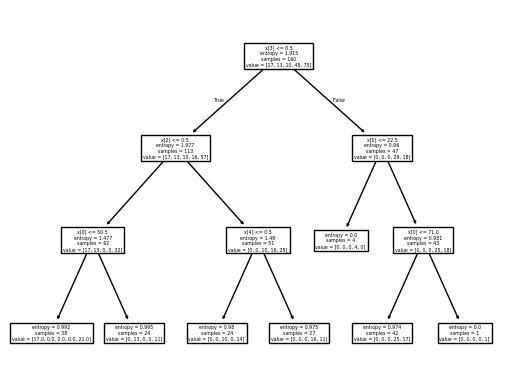

In [103]:
tree.plot_tree(dt)

In [6]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.svm import SVC

1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


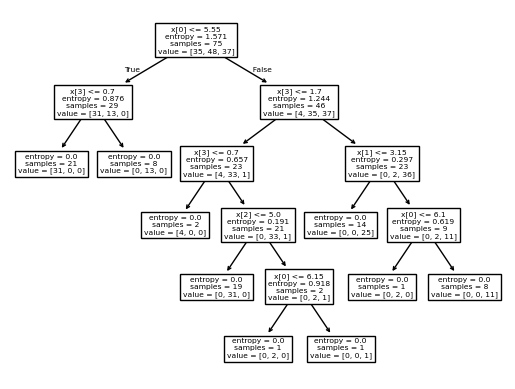

In [31]:
iris=load_iris()
x=iris.data
y=iris.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
rfc=RandomForestClassifier(n_estimators=100,criterion='entropy')
rfc.fit(x_train,y_train)
selected_tree=rfc.estimators_[0]
tree.plot_tree(selected_tree)
y_pred=rfc.predict(x_test)
y_pred
y_new=rfc.predict([[0.23,0.45,0.67,0.4]])
y_new
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)
confusion=confusion_matrix(y_test,y_pred)
print(confusion)

In [5]:
from sklearn.datasets import load_breast_cancer
cancer=load_breast_cancer()
x=cancer.data
y=cancer.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)
rfc1=RandomForestClassifier(n_estimators=100,criterion='entropy')
selected_tree1=rfc1.estimators_[0]
tree.plot_tree(selected_tree1)
rfc1.fit(x_train,y_train)
y_pred=rfc.predict(x_test)
y_pred

AttributeError: 'RandomForestClassifier' object has no attribute 'estimators_'

In [8]:
df=pd.read_csv('cancer.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [9]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [11]:
df.drop('Unnamed: 32',axis=1,inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [15]:
y=df[['diagnosis']]
x=df.drop('diagnosis',axis=1)

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)

In [19]:
svm= SVC(C=1)
svm.fit(x_train,y_train)
y_pred=svm.predict(x_test)
y_pred

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array(['B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B'], dtype=object)

In [20]:
accuracy_score(y_test,y_pred)

0.6403508771929824